In [ ]:
!pip install catboost lightgbm xgboost
!pip install iterative-stratification

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib



from iterstrat.ml_stratifiers import (
    MultilabelStratifiedShuffleSplit,
    MultilabelStratifiedKFold
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    jaccard_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.base import clone

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier




Loads and cleans the authority dataset, validates the required label columns, converts labels to numeric format, and visualizes the class distribution.

Original dataset shape: (3000, 27)

Columns: ['id', 'disaster_type', 'num_people', 'duration_band', 'children', 'elderly', 'pregnant', 'disability', 'water_rising_flag', 'near_submerged_flag', 'landslide_active_risk_flag', 'cyclone_active_risk_flag', 'trapped', 'medical_urgency_flag', 'access_blocked', 'river_overflow_flag', 'river_near_flag', 'building_damage_flag', 'mass_impact_flag', 'vulnerability_flag', 'final_escape_level_flag', 'navy', 'fire', 'ambulance', 'police', 'army', 'dmc']

Label distribution:
navy         1447
fire          843
ambulance     401
police       1773
army          908
dtype: int64


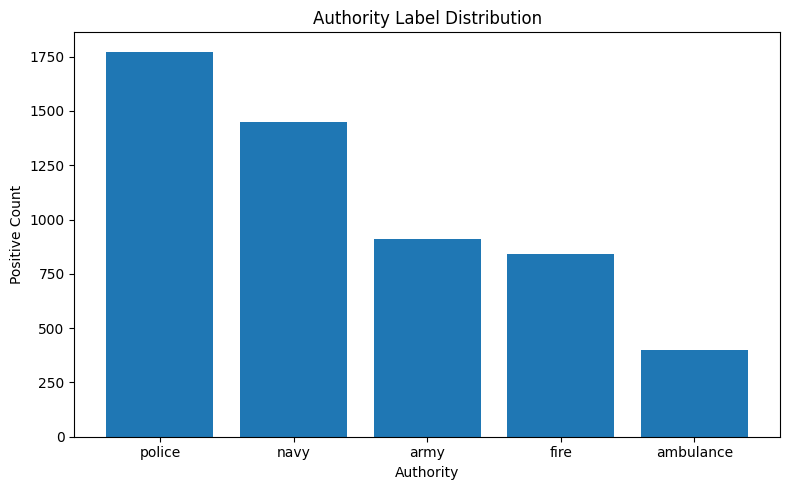

In [ ]:

input_path = "Authority_Dataset.csv"
df = pd.read_csv(input_path)

print("Original dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df = df.dropna(how="all").copy()
df.columns = df.columns.str.strip()

LABEL_COLS = ["navy", "fire", "ambulance", "police", "army"]

missing_labels = [c for c in LABEL_COLS if c not in df.columns]
if missing_labels:
    raise ValueError(f"Missing label columns: {missing_labels}")

for col in LABEL_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

print("\nLabel distribution:")
print(df[LABEL_COLS].sum())


plt.figure(figsize=(8, 5))
label_counts = df[LABEL_COLS].sum().sort_values(ascending=False)
plt.bar(label_counts.index, label_counts.values)
plt.title("Authority Label Distribution")
plt.xlabel("Authority")
plt.ylabel("Positive Count")
plt.tight_layout()
plt.savefig("chart_label_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Normalizes disaster types and visualizes disaster and authority distributions by disaster type.


Disaster type distribution:
disaster_type
flood        1356
landslide     614
cyclone       570
tsunami       460
Name: count, dtype: int64


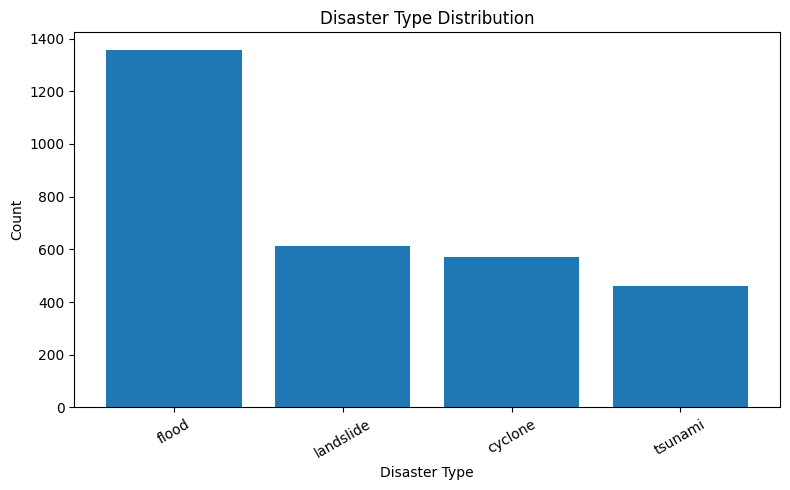

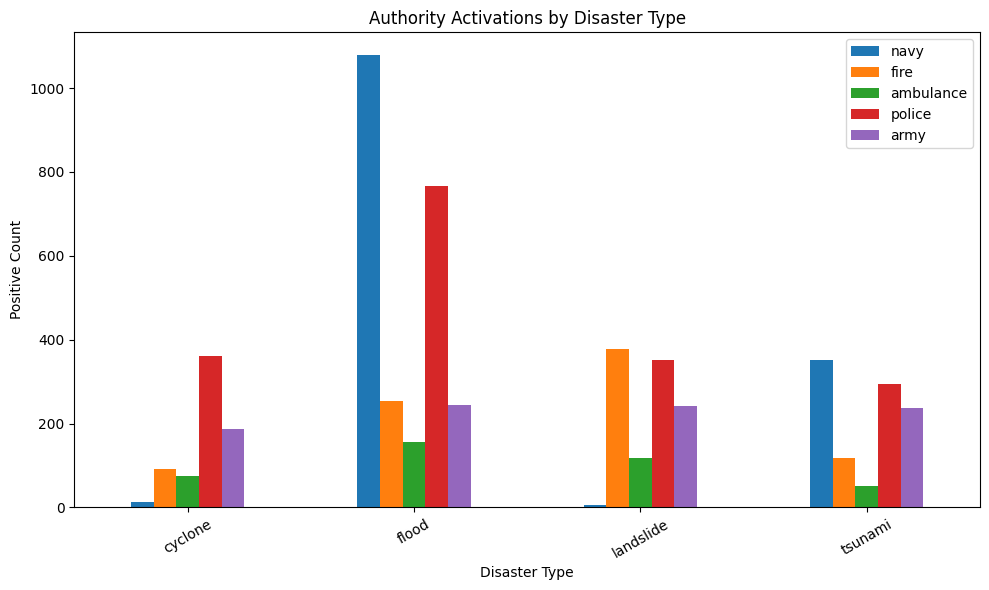

In [ ]:

if "disaster_type" in df.columns:
    df["disaster_type"] = df["disaster_type"].astype(str).str.strip().str.lower()

print("\nDisaster type distribution:")
if "disaster_type" in df.columns:
    print(df["disaster_type"].value_counts(dropna=False))

    disaster_counts = df["disaster_type"].value_counts()
    plt.figure(figsize=(8, 5))
    plt.bar(disaster_counts.index, disaster_counts.values)
    plt.title("Disaster Type Distribution")
    plt.xlabel("Disaster Type")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("chart_disaster_type_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()


    authority_by_disaster = df.groupby("disaster_type")[LABEL_COLS].sum()
    authority_by_disaster.plot(kind="bar", figsize=(10, 6))
    plt.title("Authority Activations by Disaster Type")
    plt.xlabel("Disaster Type")
    plt.ylabel("Positive Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("chart_authority_by_disaster_type.png", dpi=300, bbox_inches="tight")
    plt.show()



Removes unused and target columns, then selects the remaining input features for model training.

In [ ]:

drop_cols = [
    "id",
    "dmc",
    "duration_hours",
    "severe_case",
    "has_vulnerable_people",
    *LABEL_COLS
]
drop_cols = [c for c in drop_cols if c in df.columns]

feature_cols = [c for c in df.columns if c not in drop_cols]

X_all = df[feature_cols].copy()
Y_all = df[LABEL_COLS].copy()

print("\nFeature columns used for ML:")
print(feature_cols)




Feature columns used for ML:
['disaster_type', 'num_people', 'duration_band', 'children', 'elderly', 'pregnant', 'disability', 'water_rising_flag', 'near_submerged_flag', 'landslide_active_risk_flag', 'cyclone_active_risk_flag', 'trapped', 'medical_urgency_flag', 'access_blocked', 'river_overflow_flag', 'river_near_flag', 'building_damage_flag', 'mass_impact_flag', 'vulnerability_flag', 'final_escape_level_flag']


Removes duplicate records and compares dataset size before and after deduplication.


Rows before dedup: 3000
Rows after dedup : 2628
Duplicates removed: 372


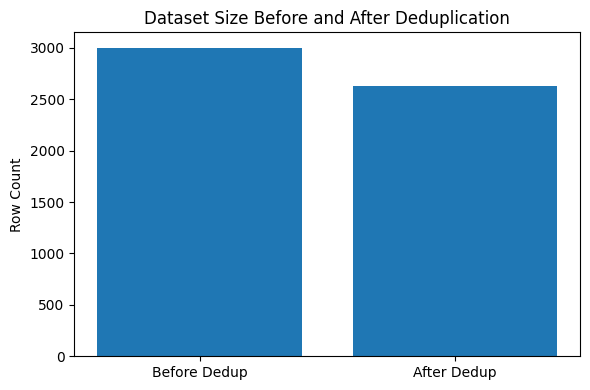

In [ ]:

dedup_cols = feature_cols + LABEL_COLS
before_dedup = len(df)
df = df.drop_duplicates(subset=dedup_cols).copy()
after_dedup = len(df)

print(f"\nRows before dedup: {before_dedup}")
print(f"Rows after dedup : {after_dedup}")
print(f"Duplicates removed: {before_dedup - after_dedup}")


plt.figure(figsize=(6, 4))
plt.bar(["Before Dedup", "After Dedup"], [before_dedup, after_dedup])
plt.title("Dataset Size Before and After Deduplication")
plt.ylabel("Row Count")
plt.tight_layout()
plt.savefig("chart_dedup_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

X_all = df[feature_cols].copy()
Y_all = df[LABEL_COLS].copy()



Separates input features into categorical and numeric columns.

In [ ]:

cat_cols = [c for c in X_all.columns if X_all[c].dtype == "object"]
num_cols = [c for c in X_all.columns if c not in cat_cols]

print("\nCategorical columns:", cat_cols)
print("Numeric columns:", num_cols)




Categorical columns: ['disaster_type', 'duration_band']
Numeric columns: ['num_people', 'children', 'elderly', 'pregnant', 'disability', 'water_rising_flag', 'near_submerged_flag', 'landslide_active_risk_flag', 'cyclone_active_risk_flag', 'trapped', 'medical_urgency_flag', 'access_blocked', 'river_overflow_flag', 'river_near_flag', 'building_damage_flag', 'mass_impact_flag', 'vulnerability_flag', 'final_escape_level_flag']


Builds the preprocessing pipeline for imputing, encoding, and scaling input features before training.

In [ ]:

print("Starting preprocessing setup...")

print("Categorical columns:", cat_cols)
print("Number of categorical columns:", len(cat_cols))

print("Numeric columns:", num_cols)
print("Number of numeric columns:", len(num_cols))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numeric transformer created.")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

print("Categorical transformer created.")

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols),
        ("num", numeric_transformer, num_cols)
    ],
    remainder="drop"
)

print("ColumnTransformer created successfully.")
print("Preprocessing pipeline is ready.")

Starting preprocessing setup...
Categorical columns: ['disaster_type', 'duration_band']
Number of categorical columns: 2
Numeric columns: ['num_people', 'children', 'elderly', 'pregnant', 'disability', 'water_rising_flag', 'near_submerged_flag', 'landslide_active_risk_flag', 'cyclone_active_risk_flag', 'trapped', 'medical_urgency_flag', 'access_blocked', 'river_overflow_flag', 'river_near_flag', 'building_damage_flag', 'mass_impact_flag', 'vulnerability_flag', 'final_escape_level_flag']
Number of numeric columns: 18
Numeric transformer created.
Categorical transformer created.
ColumnTransformer created successfully.
Preprocessing pipeline is ready.


Splits the dataset into stratified train, validation, and test sets while preserving multilabel class balance, then visualizes the split sizes and label distributions.


Train shape: (1681, 20)
Validation shape: (421, 20)
Test shape: (526, 20)

Train label distribution:
navy          830
fire          515
ambulance     254
police       1085
army          562
dtype: int64

Validation label distribution:
navy         208
fire         129
ambulance     64
police       272
army         141
dtype: int64

Test label distribution:
navy         260
fire         161
ambulance     79
police       339
army         176
dtype: int64


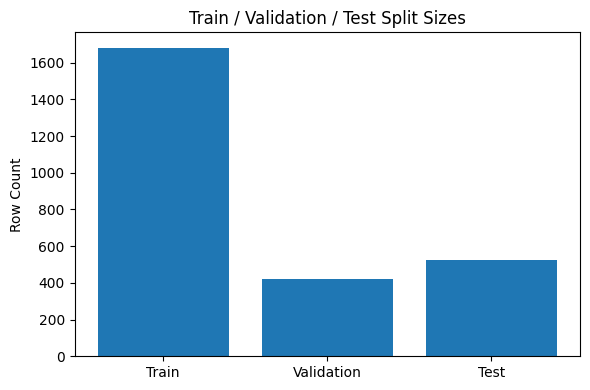

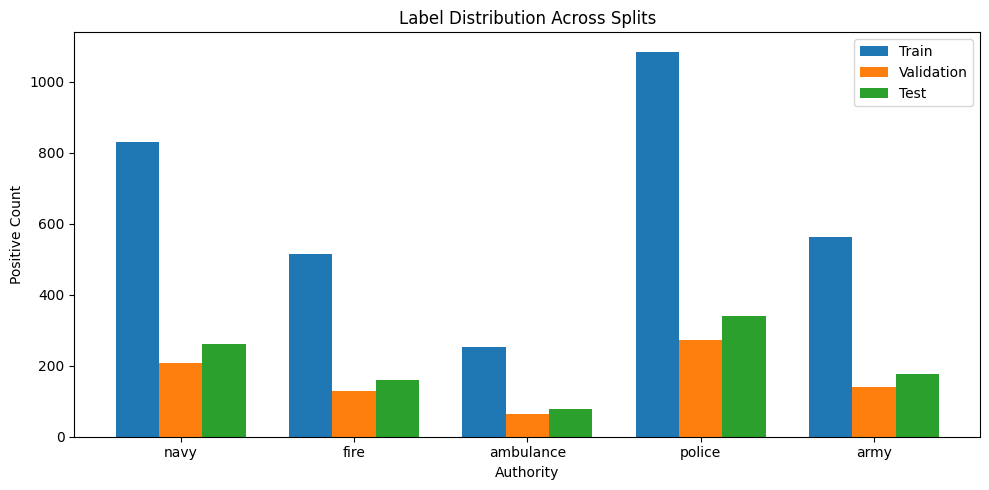

Saved: authority_train_split.csv
Saved: authority_validation_split.csv
Saved: authority_test_split.csv


In [ ]:

msss_outer = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.20, random_state=42
)
train_full_idx, test_idx = next(msss_outer.split(X_all, Y_all))

X_train_full = X_all.iloc[train_full_idx].reset_index(drop=True)
Y_train_full = Y_all.iloc[train_full_idx].reset_index(drop=True)

X_test = X_all.iloc[test_idx].reset_index(drop=True)
Y_test = Y_all.iloc[test_idx].reset_index(drop=True)

msss_inner = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.20, random_state=42
)
train_idx, val_idx = next(msss_inner.split(X_train_full, Y_train_full))

X_train = X_train_full.iloc[train_idx].reset_index(drop=True)
Y_train = Y_train_full.iloc[train_idx].reset_index(drop=True)

X_val = X_train_full.iloc[val_idx].reset_index(drop=True)
Y_val = Y_train_full.iloc[val_idx].reset_index(drop=True)

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:")
print(Y_train.sum())

print("\nValidation label distribution:")
print(Y_val.sum())

print("\nTest label distribution:")
print(Y_test.sum())


plt.figure(figsize=(6, 4))
plt.bar(["Train", "Validation", "Test"], [len(X_train), len(X_val), len(X_test)])
plt.title("Train / Validation / Test Split Sizes")
plt.ylabel("Row Count")
plt.tight_layout()
plt.savefig("chart_split_sizes.png", dpi=300, bbox_inches="tight")
plt.show()


train_counts = Y_train.sum()
val_counts = Y_val.sum()
test_counts = Y_test.sum()

x = np.arange(len(LABEL_COLS))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, train_counts.values, width=width, label="Train")
plt.bar(x, val_counts.values, width=width, label="Validation")
plt.bar(x + width, test_counts.values, width=width, label="Test")
plt.xticks(x, LABEL_COLS)
plt.title("Label Distribution Across Splits")
plt.xlabel("Authority")
plt.ylabel("Positive Count")
plt.legend()
plt.tight_layout()
plt.savefig("chart_label_distribution_across_splits.png", dpi=300, bbox_inches="tight")
plt.show()

train_data = pd.concat([X_train, Y_train], axis=1)
val_data = pd.concat([X_val, Y_val], axis=1)
test_data = pd.concat([X_test, Y_test], axis=1)

train_data.to_csv("authority_train_split.csv", index=False)
val_data.to_csv("authority_validation_split.csv", index=False)
test_data.to_csv("authority_test_split.csv", index=False)

print("Saved: authority_train_split.csv")
print("Saved: authority_validation_split.csv")
print("Saved: authority_test_split.csv")



Defines a function to measure exact-match accuracy across all labels for each sample.

In [ ]:

def subset_accuracy(y_true, y_pred):
    return np.mean(np.all(y_true == y_pred, axis=1))

print("Subset accuracy function created successfully.")

Subset accuracy function created successfully.


Defines multiple multilabel classification pipelines to compare different models for authority prediction.

In [ ]:

models = {
    "OneVsRest_LogisticRegression": Pipeline([
        ("prep", preprocess),
        ("clf", OneVsRestClassifier(
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42
            )
        ))
    ]),

    "RandomForest_MultiOutput": Pipeline([
        ("prep", preprocess),
        ("clf", MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        ))
    ]),

    "HistGradientBoosting_MultiOutput": Pipeline([
        ("prep", preprocess),
        ("clf", MultiOutputClassifier(
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_depth=5,
                max_iter=250,
                random_state=42
            )
        ))
    ]),

    "OneVsRest_XGBoost": Pipeline([
        ("prep", preprocess),
        ("clf", OneVsRestClassifier(
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        ))
    ]),

    "OneVsRest_LightGBM": Pipeline([
        ("prep", preprocess),
        ("clf", OneVsRestClassifier(
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=-1,
                num_leaves=31,
                subsample=0.9,
                colsample_bytree=0.9,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )
        ))
    ]),

    "OneVsRest_CatBoost": Pipeline([
        ("prep", preprocess),
        ("clf", OneVsRestClassifier(
            CatBoostClassifier(
                iterations=300,
                depth=6,
                learning_rate=0.05,
                loss_function="Logloss",
                verbose=0,
                random_state=42
            )
        ))
    ]),

    "ClassifierChain_LogisticRegression": Pipeline([
        ("prep", preprocess),
        ("clf", ClassifierChain(
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42
            ),
            order="random",
            random_state=42
        ))
    ])
}



Runs 5-fold multilabel-stratified cross-validation to compare model performance and select the best classifier.


RUNNING 5-FOLD MULTILABEL-STRATIFIED CV ON TRAIN SET
OneVsRest_LogisticRegression done.
RandomForest_MultiOutput done.
HistGradientBoosting_MultiOutput done.
OneVsRest_XGBoost done.
OneVsRest_LightGBM done.
OneVsRest_CatBoost done.
ClassifierChain_LogisticRegression done.

CV RESULTS
                                model  f1_micro_mean  f1_macro_mean  \
1            RandomForest_MultiOutput       0.943725       0.933308   
3                   OneVsRest_XGBoost       0.942433       0.932602   
5                  OneVsRest_CatBoost       0.941576       0.930201   
2    HistGradientBoosting_MultiOutput       0.939427       0.927143   
4                  OneVsRest_LightGBM       0.929992       0.917743   
0        OneVsRest_LogisticRegression       0.906366       0.895467   
6  ClassifierChain_LogisticRegression       0.903312       0.894449   

   f1_samples_mean  jaccard_samples_mean  
1         0.828079              0.808716  
3         0.826288              0.806753  
5         0.8246

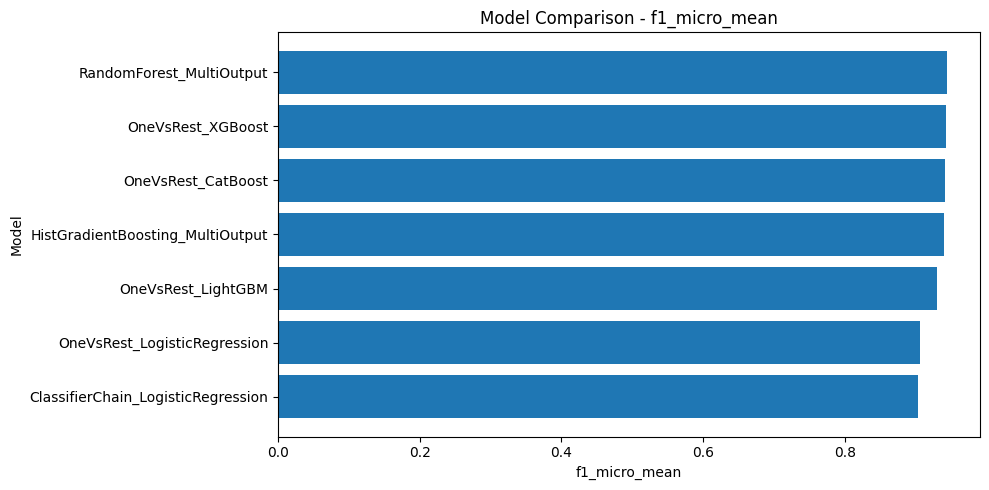

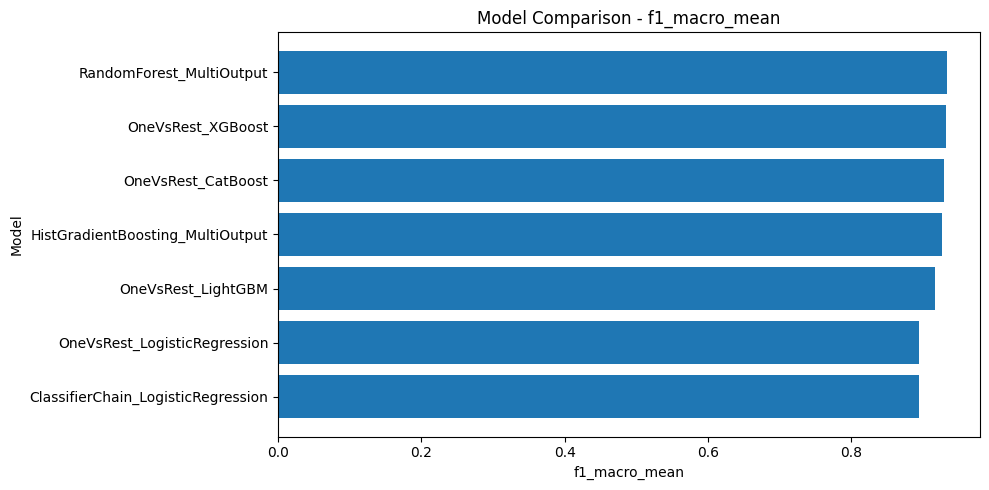

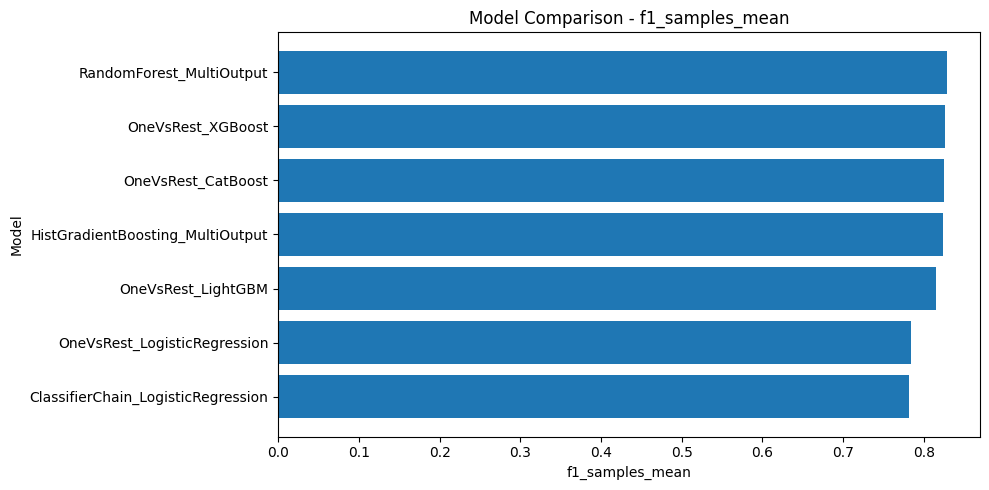

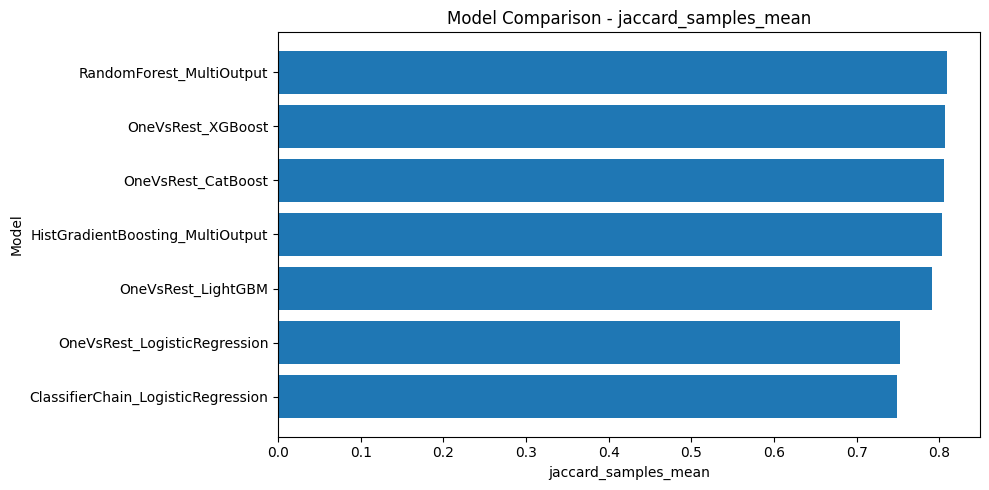

In [ ]:

cv = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
print("\n" + "=" * 80)
print("RUNNING 5-FOLD MULTILABEL-STRATIFIED CV ON TRAIN SET")

for name, pipe in models.items():
    fold_micro = []
    fold_macro = []
    fold_samples = []
    fold_jaccard = []

    try:
        for tr_idx, va_idx in cv.split(X_train, Y_train):
            X_tr = X_train.iloc[tr_idx]
            Y_tr = Y_train.iloc[tr_idx]
            X_va = X_train.iloc[va_idx]
            Y_va = Y_train.iloc[va_idx]

            model = clone(pipe)
            model.fit(X_tr, Y_tr)
            pred = model.predict(X_va)

            fold_micro.append(f1_score(Y_va, pred, average="micro", zero_division=0))
            fold_macro.append(f1_score(Y_va, pred, average="macro", zero_division=0))
            fold_samples.append(f1_score(Y_va, pred, average="samples", zero_division=0))
            fold_jaccard.append(jaccard_score(Y_va, pred, average="samples", zero_division=0))

        rows.append({
            "model": name,
            "f1_micro_mean": np.mean(fold_micro),
            "f1_macro_mean": np.mean(fold_macro),
            "f1_samples_mean": np.mean(fold_samples),
            "jaccard_samples_mean": np.mean(fold_jaccard)
        })

        print(f"{name} done.")

    except Exception as e:
        print(f"{name} failed: {e}")

results_df = pd.DataFrame(rows).sort_values("f1_macro_mean", ascending=False)

print("\nCV RESULTS")
print(results_df)

best_model_name = results_df.iloc[0]["model"]
best_pipe = clone(models[best_model_name])

print("\nBest model from CV:", best_model_name)


for metric in ["f1_micro_mean", "f1_macro_mean", "f1_samples_mean", "jaccard_samples_mean"]:
    ordered = results_df.sort_values(metric, ascending=True)
    plt.figure(figsize=(10, 5))
    plt.barh(ordered["model"], ordered[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.xlabel(metric)
    plt.ylabel("Model")
    plt.tight_layout()
    plt.savefig(f"chart_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()



Trains the selected best-performing model on the training data.

In [ ]:

best_pipe.fit(X_train, Y_train)



Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['disaster_type',
                                                   'duration_band']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_people',...
                                                   'cyclone_active_risk_flag',
                                                   'trapped',
                                                   'medical_urgency_flag',
                                                   'access_blocked',
                                                   'river_overflow_flag',
                                                   'river_near_flag',
                                                   'building_damage_flag',
                                                   'mass_impact_flag',
                                                   'vulnerability_flag',
                                                   'final_escape_level_flag'])])),
                ('clf',
                 MultiOutputClassifier(estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                                                        min_samples_leaf=2,
                                                                        n_estimators=400,
                                                                        n_jobs=-1,
                                                                        random_state=42)))])

Defines a function to extract multilabel prediction probabilities from the trained model for validation and threshold tuning.

In [ ]:

def get_multilabel_proba(model, X_data):
    X_t = model.named_steps["prep"].transform(X_data)
    clf = model.named_steps["clf"]

    if isinstance(clf, OneVsRestClassifier):
        proba = clf.predict_proba(X_t)

        if isinstance(proba, list):
            probs = []
            for p in proba:
                if p.ndim == 2 and p.shape[1] >= 2:
                    probs.append(p[:, 1])
                else:
                    probs.append(np.ravel(p))
            return np.column_stack(probs)

        proba = np.asarray(proba)
        if proba.ndim == 1:
            proba = proba.reshape(-1, 1)
        return proba

    elif isinstance(clf, MultiOutputClassifier):
        prob_list = clf.predict_proba(X_t)
        probs = []
        for p in prob_list:
            if p.ndim == 2 and p.shape[1] >= 2:
                probs.append(p[:, 1])
            else:
                probs.append(np.ravel(p))
        return np.column_stack(probs)

    elif isinstance(clf, ClassifierChain):
        if hasattr(clf, "predict_proba"):
            prob_list = clf.predict_proba(X_t)
            probs = []

            if isinstance(prob_list, list):
                for p in prob_list:
                    if p.ndim == 2 and p.shape[1] >= 2:
                        probs.append(p[:, 1])
                    else:
                        probs.append(np.ravel(p))
                return np.column_stack(probs)

            prob_list = np.asarray(prob_list)
            if prob_list.ndim == 2:
                return prob_list
            elif prob_list.ndim == 3:
                for i in range(prob_list.shape[0]):
                    p = prob_list[i]
                    if p.ndim == 2 and p.shape[1] >= 2:
                        probs.append(p[:, 1])
                    else:
                        probs.append(np.ravel(p))
                return np.column_stack(probs)

        raise ValueError("ClassifierChain probability extraction failed.")

    else:
        raise ValueError(f"Unsupported classifier type: {type(clf)}")

val_proba = get_multilabel_proba(best_pipe, X_val)

print("\nY_val shape:", Y_val.shape)
print("val_proba shape:", val_proba.shape)
print("Classifier type:", type(best_pipe.named_steps["clf"]))




Y_val shape: (421, 5)
val_proba shape: (421, 5)
Classifier type: <class 'sklearn.multioutput.MultiOutputClassifier'>


Tunes the decision threshold for each authority label using validation F1 score and visualizes the best thresholds and label-wise performance.


Best thresholds per label:
{'navy': 0.45, 'fire': 0.45, 'ambulance': 0.55, 'police': 0.4, 'army': 0.4}

Validation label-wise F1 after threshold tuning:
navy: 0.9617
fire: 0.9312
ambulance: 0.9280
police: 0.9584
army: 0.9097


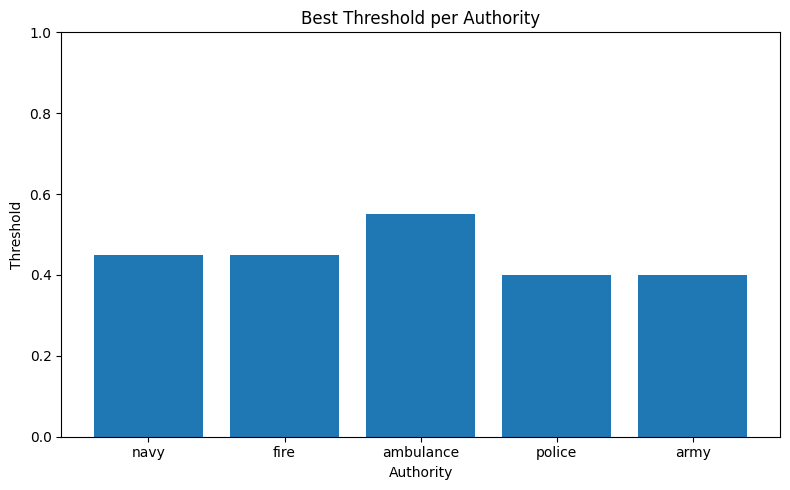

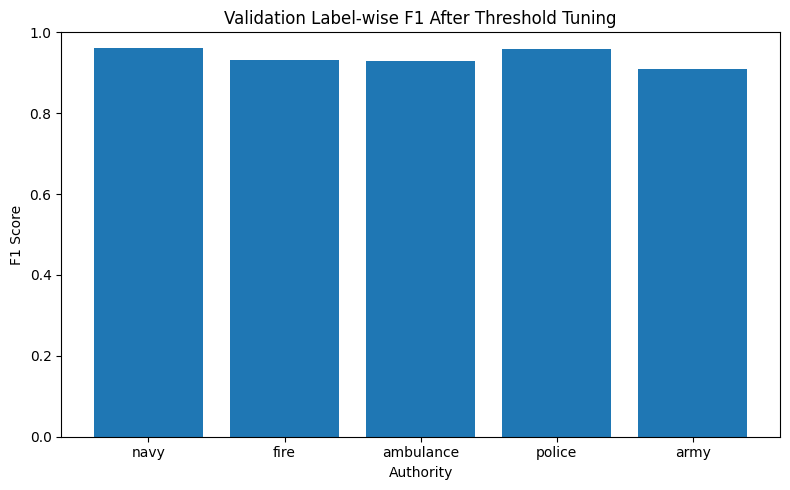

In [ ]:

def tune_thresholds(y_true_df, proba, label_cols):
    thresholds = {}
    best_scores = {}

    y_true_array = y_true_df[label_cols].values

    for i, label in enumerate(label_cols):
        y_true = y_true_array[:, i]
        y_prob = proba[:, i]

        best_t = 0.50
        best_f1 = -1

        for t in np.arange(0.20, 0.81, 0.05):
            y_pred = (y_prob >= t).astype(int)
            score = f1_score(y_true, y_pred, zero_division=0)

            if score > best_f1:
                best_f1 = score
                best_t = round(float(t), 2)

        thresholds[label] = best_t
        best_scores[label] = best_f1

    return thresholds, best_scores

best_thresholds, val_label_f1 = tune_thresholds(Y_val, val_proba, LABEL_COLS)

print("\nBest thresholds per label:")
print(best_thresholds)

print("\nValidation label-wise F1 after threshold tuning:")
for k, v in val_label_f1.items():
    print(f"{k}: {v:.4f}")


plt.figure(figsize=(8, 5))
plt.bar(best_thresholds.keys(), best_thresholds.values())
plt.title("Best Threshold per Authority")
plt.xlabel("Authority")
plt.ylabel("Threshold")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("chart_best_thresholds.png", dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(val_label_f1.keys(), val_label_f1.values())
plt.title("Validation Label-wise F1 After Threshold Tuning")
plt.xlabel("Authority")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("chart_validation_label_f1.png", dpi=300, bbox_inches="tight")
plt.show()



Applies the tuned label-specific thresholds to convert prediction probabilities into final multilabel outputs.

In [ ]:

def predict_with_thresholds(model, X_data, thresholds, label_cols):
    proba = get_multilabel_proba(model, X_data)
    pred = np.zeros_like(proba, dtype=int)

    for i, label in enumerate(label_cols):
        pred[:, i] = (proba[:, i] >= thresholds[label]).astype(int)

    return pred, proba



Generates final test predictions using the tuned thresholds, evaluates overall multilabel performance, and visualizes the test metrics.


TEST RESULTS - ML ONLY
Subset Accuracy: 0.8327
Hamming Loss: 0.0418
F1 Micro: 0.9463
F1 Macro: 0.9340
F1 Samples: 0.8365
Jaccard Samples: 0.8170


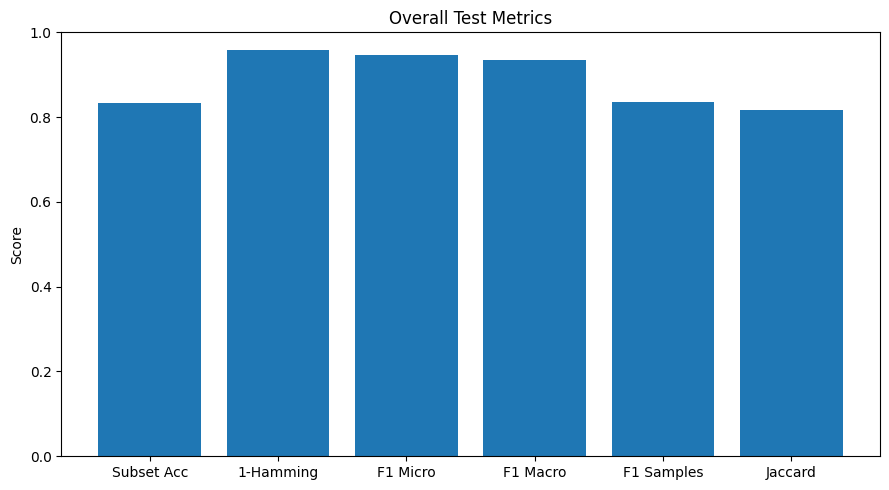

In [ ]:

Y_test_pred, Y_test_proba = predict_with_thresholds(
    best_pipe, X_test, best_thresholds, LABEL_COLS
)

Y_test_true = Y_test.values

test_subset_acc = subset_accuracy(Y_test_true, Y_test_pred)
test_hamming = hamming_loss(Y_test_true, Y_test_pred)
test_f1_micro = f1_score(Y_test_true, Y_test_pred, average='micro', zero_division=0)
test_f1_macro = f1_score(Y_test_true, Y_test_pred, average='macro', zero_division=0)
test_f1_samples = f1_score(Y_test_true, Y_test_pred, average='samples', zero_division=0)
test_jaccard = jaccard_score(Y_test_true, Y_test_pred, average='samples', zero_division=0)

print("\n" + "=" * 80)
print("TEST RESULTS - ML ONLY")
print(f"Subset Accuracy: {test_subset_acc:.4f}")
print(f"Hamming Loss: {test_hamming:.4f}")
print(f"F1 Micro: {test_f1_micro:.4f}")
print(f"F1 Macro: {test_f1_macro:.4f}")
print(f"F1 Samples: {test_f1_samples:.4f}")
print(f"Jaccard Samples: {test_jaccard:.4f}")


metric_names = ["Subset Acc", "1-Hamming", "F1 Micro", "F1 Macro", "F1 Samples", "Jaccard"]
metric_vals = [
    test_subset_acc,
    1 - test_hamming,
    test_f1_micro,
    test_f1_macro,
    test_f1_samples,
    test_jaccard
]

plt.figure(figsize=(9, 5))
plt.bar(metric_names, metric_vals)
plt.title("Overall Test Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("chart_overall_test_metrics.png", dpi=300, bbox_inches="tight")
plt.show()



Prints a classification report for each authority label and visualizes label-wise F1 scores and confusion matrices.


LABEL-WISE CLASSIFICATION REPORT - ML ONLY

--- NAVY ---
              precision    recall  f1-score   support

    not_navy       0.98      0.94      0.96       266
        navy       0.94      0.98      0.96       260

    accuracy                           0.96       526
   macro avg       0.96      0.96      0.96       526
weighted avg       0.96      0.96      0.96       526


--- FIRE ---
              precision    recall  f1-score   support

    not_fire       0.95      0.99      0.97       365
        fire       0.97      0.87      0.92       161

    accuracy                           0.95       526
   macro avg       0.96      0.93      0.94       526
weighted avg       0.95      0.95      0.95       526


--- AMBULANCE ---
               precision    recall  f1-score   support

not_ambulance       0.98      0.98      0.98       447
    ambulance       0.89      0.89      0.89        79

     accuracy                           0.97       526
    macro avg       0.93      0.9

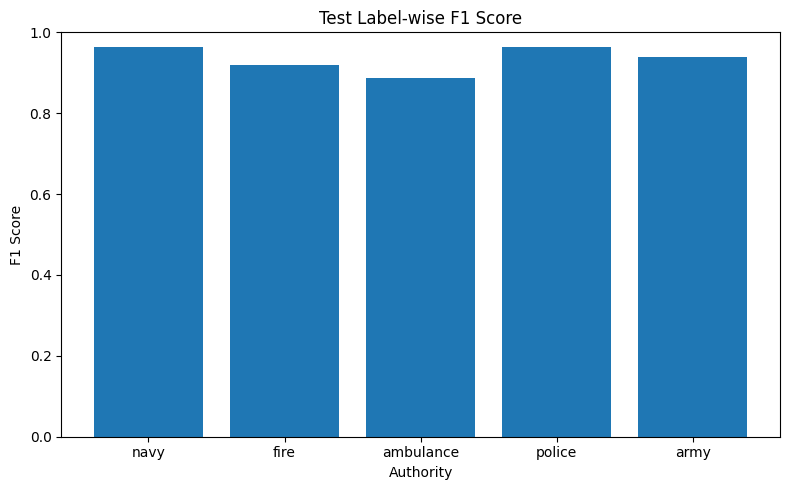

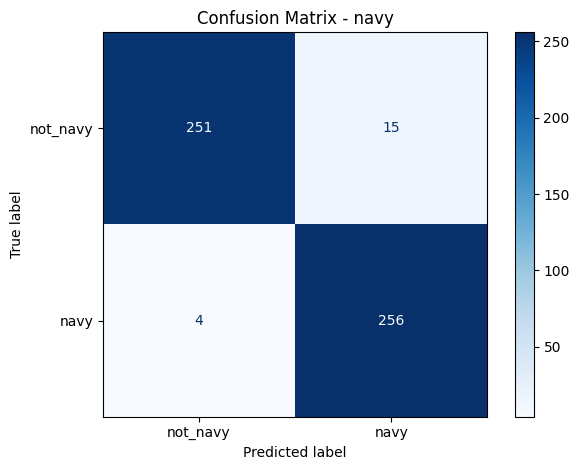

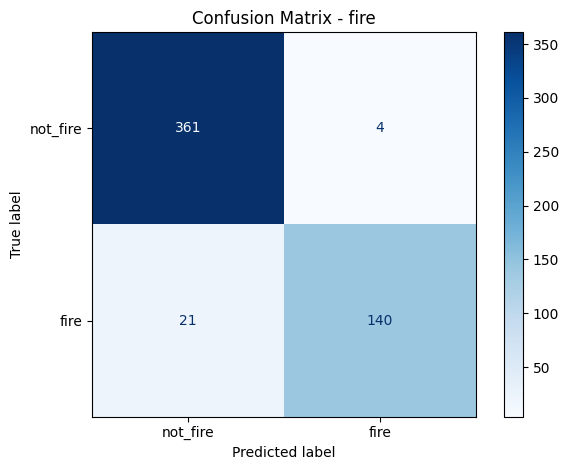

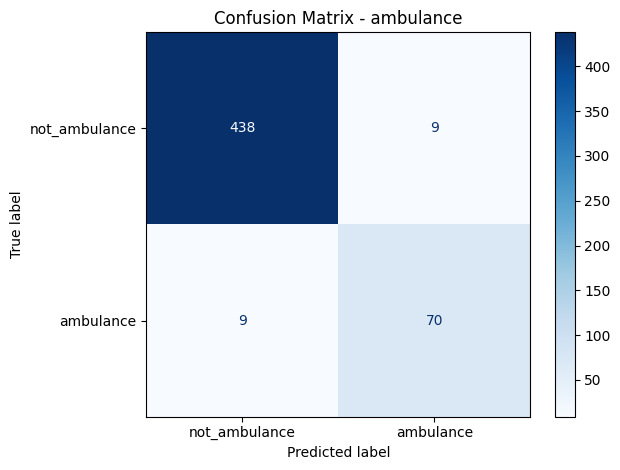

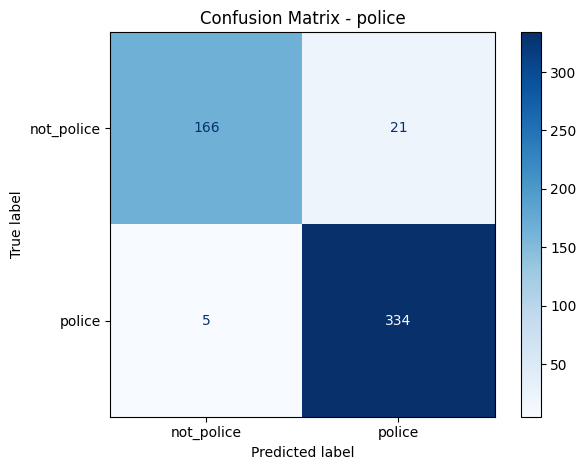

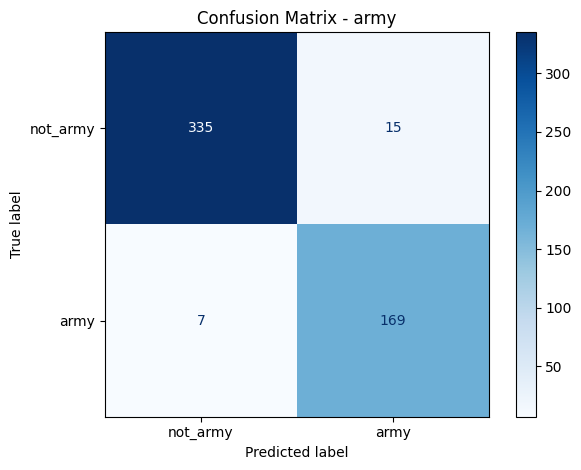

In [ ]:

print("\n" + "=" * 80)
print("LABEL-WISE CLASSIFICATION REPORT - ML ONLY")

label_f1_scores = {}

for i, label in enumerate(LABEL_COLS):
    print(f"\n--- {label.upper()} ---")
    print(classification_report(
        Y_test_true[:, i],
        Y_test_pred[:, i],
        target_names=[f"not_{label}", label],
        zero_division=0
    ))

    label_f1_scores[label] = f1_score(Y_test_true[:, i], Y_test_pred[:, i], zero_division=0)


plt.figure(figsize=(8, 5))
plt.bar(label_f1_scores.keys(), label_f1_scores.values())
plt.title("Test Label-wise F1 Score")
plt.xlabel("Authority")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("chart_test_labelwise_f1.png", dpi=300, bbox_inches="tight")
plt.show()


for i, label in enumerate(LABEL_COLS):
    cm = confusion_matrix(Y_test_true[:, i], Y_test_pred[:, i], labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f"not_{label}", label]
    )
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {label}")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{label}.png", dpi=300, bbox_inches="tight")
    plt.show()



Calculates permutation-based feature importance on the test set to identify which input features contribute most to multilabel prediction performance.


Calculating Feature Importance...

Top Important Features:
                       feature  importance
0                disaster_type    0.318631
13              access_blocked    0.204563
1                   num_people    0.189354
16        building_damage_flag    0.184030
18          vulnerability_flag    0.168441
17            mass_impact_flag    0.160456
12        medical_urgency_flag    0.125095
11                     trapped    0.119392
9   landslide_active_risk_flag    0.103802
7            water_rising_flag    0.090875


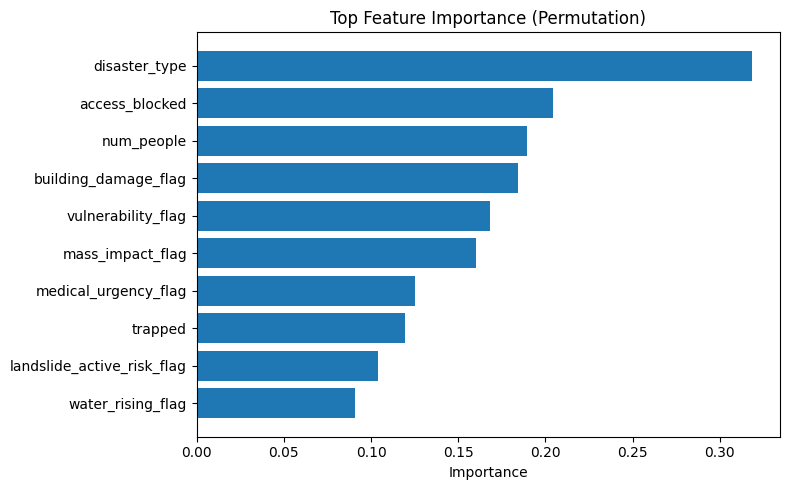

Feature importance could not be calculated: Invalid extension for engine '<property object at 0x7cf24206d620>': 'csv'


In [ ]:

print("\nCalculating Feature Importance...")

def multilabel_subset_scorer(estimator, X_data, y_true):
    y_pred = estimator.predict(X_data)
    return np.mean(np.all(y_true.values == y_pred, axis=1))

try:
    result = permutation_importance(
        best_pipe,
        X_test,
        Y_test,
        scoring=multilabel_subset_scorer,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    fi = pd.DataFrame({
        "feature": X_all.columns,
        "importance": result.importances_mean
    }).sort_values("importance", ascending=False)

    print("\nTop Important Features:")
    print(fi.head(10))

    plt.figure(figsize=(8, 5))
    plt.barh(fi["feature"].head(10)[::-1], fi["importance"].head(10)[::-1])
    plt.title("Top Feature Importance (Permutation)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("chart_feature_importance_top10.png", dpi=300, bbox_inches="tight")
    plt.show()

    fi.to_excel("feature_importance_full.csv", index=False, engine="openpyxl")

except Exception as e:
    print("Feature importance could not be calculated:", e)



Performs a label-shuffle leakage test to verify that the model’s performance depends on real feature-label relationships rather than data leakage.


Running leakage test (label shuffle)...
F1 Micro after label shuffle: 0.4604090194022024


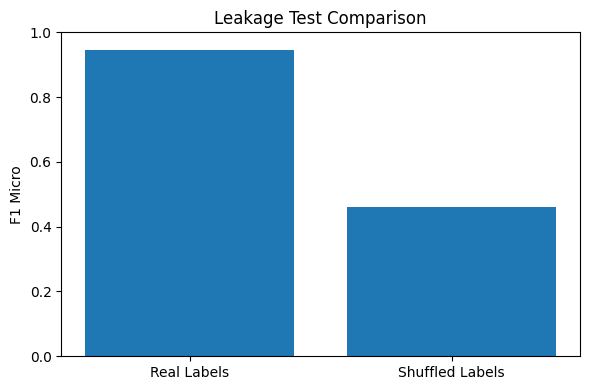

In [ ]:

print("\nRunning leakage test (label shuffle)...")

Y_train_shuffled = Y_train.sample(frac=1, random_state=42).reset_index(drop=True)
X_train_reset = X_train.reset_index(drop=True)

leak_model = clone(models[best_model_name])
leak_model.fit(X_train_reset, Y_train_shuffled)

shuffle_pred = leak_model.predict(X_test)
shuffle_f1_micro = f1_score(Y_test.values, shuffle_pred, average="micro", zero_division=0)

print("F1 Micro after label shuffle:", shuffle_f1_micro)


plt.figure(figsize=(6, 4))
plt.bar(["Real Labels", "Shuffled Labels"], [test_f1_micro, shuffle_f1_micro])
plt.title("Leakage Test Comparison")
plt.ylabel("F1 Micro")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("chart_leakage_test_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



Trains the final authority prediction model on the full training data and saves the model, thresholds, label names, and feature columns for deployment.

In [ ]:

final_model = clone(models[best_model_name])
final_model.fit(X_train_full, Y_train_full)

joblib.dump(final_model, "best_authority_multilabel_model.joblib")
joblib.dump(best_thresholds, "best_authority_thresholds.joblib")
joblib.dump(LABEL_COLS, "authority_label_names.joblib")
joblib.dump(feature_cols, "authority_feature_columns.joblib")

print("\nFinal model saved: best_authority_multilabel_model.joblib")
print("Thresholds saved: best_authority_thresholds.joblib")
print("Label names saved: authority_label_names.joblib")
print("Feature columns saved: authority_feature_columns.joblib")




Final model saved: best_authority_multilabel_model.joblib
Thresholds saved: best_authority_thresholds.joblib
Label names saved: authority_label_names.joblib
Feature columns saved: authority_feature_columns.joblib


Saves the model comparison results for later analysis and reporting.

In [ ]:

results_df.to_csv("authority_model_comparison_results.csv", index=False)
print("Model comparison saved: authority_model_comparison_results.csv")


Model comparison saved: authority_model_comparison_results.csv


Manual Tester


MANUAL TEST RESULT
   authority  probability  threshold  predicted
0       navy       0.9209       0.45          1
1       fire       0.0782       0.45          0
2  ambulance       0.0118       0.55          0
3     police       0.4069       0.40          1
4       army       0.0243       0.40          0
Final authorities: ['navy', 'police']


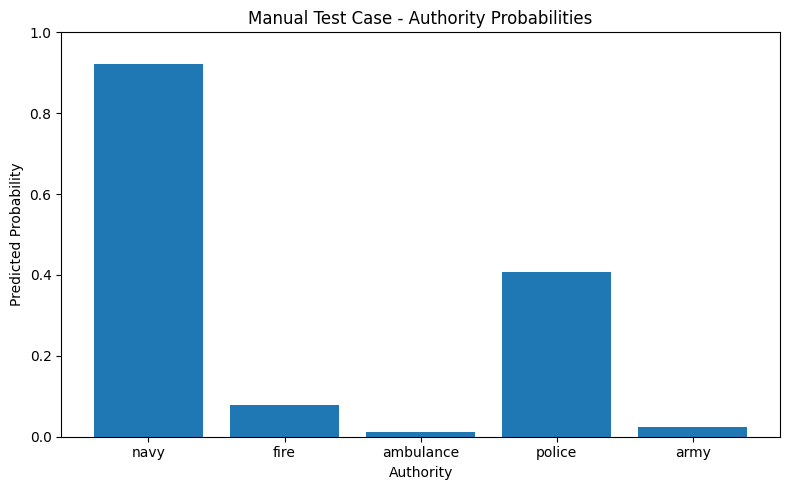

In [ ]:

manual_case = pd.DataFrame([{
    "disaster_type": "flood",
    "num_people": 8,
    "duration_band": "6-24h",
    "children": 0,
    "elderly": 1,
    "pregnant": 0,
    "disability": 0,
    "water_rising_flag": 1,
    "near_submerged_flag": 0,
    "landslide_active_risk_flag": 0,
    "cyclone_active_risk_flag": 0,
    "trapped": 0,
    "medical_urgency_flag": 0,
    "access_blocked": 0,
    "river_overflow_flag": 0,
    "river_near_flag": 0,
    "building_damage_flag": 0,
    "mass_impact_flag": 0,
    "vulnerability_flag": 0,
    "final_escape_level_flag": 0
}])

manual_case = manual_case[feature_cols]

manual_pred, manual_proba = predict_with_thresholds(
    final_model, manual_case, best_thresholds, LABEL_COLS
)

manual_result = pd.DataFrame({
    "authority": LABEL_COLS,
    "probability": np.round(manual_proba[0], 4),
    "threshold": [best_thresholds[a] for a in LABEL_COLS],
    "predicted": manual_pred[0]
})

print("\nMANUAL TEST RESULT")
print(manual_result)
print("Final authorities:", manual_result.loc[manual_result["predicted"] == 1, "authority"].tolist())


plt.figure(figsize=(8, 5))
plt.bar(manual_result["authority"], manual_result["probability"])
plt.title("Manual Test Case - Authority Probabilities")
plt.xlabel("Authority")
plt.ylabel("Predicted Probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("chart_manual_case_probabilities.png", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:

summary_df = pd.DataFrame([{
    "best_model": best_model_name,
    "subset_accuracy": test_subset_acc,
    "hamming_loss": test_hamming,
    "f1_micro": test_f1_micro,
    "f1_macro": test_f1_macro,
    "f1_samples": test_f1_samples,
    "jaccard_samples": test_jaccard,
    "shuffle_f1_micro": shuffle_f1_micro
}])

summary_df.to_csv("authority_test_summary.csv", index=False)
print("Saved: authority_test_summary.csv")

Saved: authority_test_summary.csv


In [ ]:
import zipfile
from google.colab import files

files_to_download = [
    "best_authority_multilabel_model.joblib",
    "best_authority_thresholds.joblib",
    "authority_label_names.joblib"
]

with zipfile.ZipFile("authority_model.zip", "w") as z:
    for f in files_to_download:
        z.write(f)

files.download("authority_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>